
#ECG ptb binary classifier

> Add blockquote


---



In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

normal = pd.read_csv('ptbdb_normal.csv', header=None)
abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)

normal['label'] = 0
abnormal['label'] = 1

data = pd.concat([normal, abnormal], axis=0).reset_index(drop=True)

X = data.iloc[:, :-1].values
y = data['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ECGDataset(X_train, y_train)
val_ds   = ECGDataset(X_val, y_val)
test_ds  = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

def create_padding_mask(x):
    return (x != 0)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class EncoderLayerWithAttention(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            d_model, nhead, batch_first=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask):
        attn_out, attn_weights = self.self_attn(
            x, x, x,
            key_padding_mask=~padding_mask,
            need_weights=True
        )
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, attn_weights

class ECGTransformer(nn.Module):
    def __init__(self, seq_len, d_model=64, nhead=4):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        self.positional_encoding = PositionalEncoding(d_model, seq_len)
        self.encoder = EncoderLayerWithAttention(d_model, nhead)
        self.classifier = nn.Linear(d_model, 2)

    def forward(self, x):
        padding_mask = create_padding_mask(x)
        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.positional_encoding(x)
        x, attn_weights = self.encoder(x, padding_mask)
        padding_mask = padding_mask.unsqueeze(-1)
        x = (x * padding_mask).sum(dim=1) / padding_mask.sum(dim=1)
        logits = self.classifier(x)
        return logits, attn_weights

class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss <= self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = model.state_dict()
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ECGTransformer(seq_len=X.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=3)

EPOCHS = 7
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += xb.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"--> Best model saved with val_acc: {val_acc:.4f}")

    if early_stopping.step(val_loss, model):
        print("Early stopping triggered")
        break

model.load_state_dict(early_stopping.best_state)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits, _ = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

print(classification_report(all_labels, all_preds))


Epoch  1 | Train Loss: 0.1584 | Train Acc: 0.9272 | Val Loss: 0.0007 | Val Acc: 1.0000
--> Best model saved with val_acc: 1.0000
Epoch  2 | Train Loss: 0.0005 | Train Acc: 1.0000 | Val Loss: 0.0004 | Val Acc: 1.0000
Epoch  3 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.0002 | Val Acc: 1.0000
Epoch  4 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.0002 | Val Acc: 1.0000
Epoch  5 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch  6 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch  7 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0001 | Val Acc: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       607
           1       1.00      1.00      1.00      1576

    accuracy                           1.00      2183
   macro avg       1.00      1.00      1.00      2183
weighted avg       1.00      1.00      1.00      2183



True label: 1, Predicted: 1


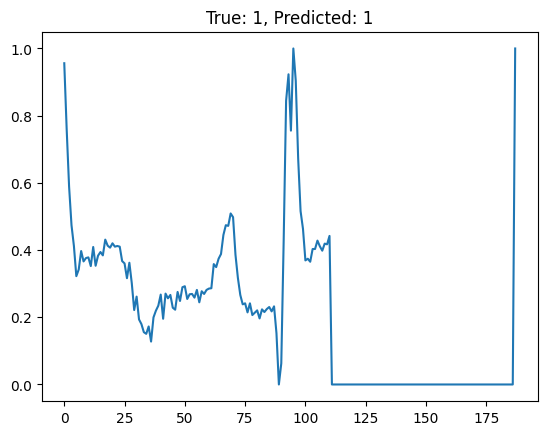

In [ ]:

# ========== نحوه انجام inference روی یک نمونه جدید ==========
best_model = ECGTransformer(seq_len=X.shape[1]).to(device)
best_model.load_state_dict(torch.load('best_model.pt'))
best_model.eval()

# انتخاب یک نمونه تصادفی از داده‌های تست
idx = np.random.randint(0, len(X_test))
sample = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
true_label = y_test[idx]

with torch.no_grad():
    logits, _ = best_model(sample)
    pred = logits.argmax(dim=1).item()

print(f"True label: {true_label}, Predicted: {pred}")


plt.plot(sample.cpu().numpy().flatten())
plt.title(f"True: {true_label}, Predicted: {pred}")
plt.show()